In [ ]:

import sys
import shutil
from pathlib import Path

# Define the root directory to search (often your current working directory or a project path)
# We can also search system-wide if needed, but starting local is safer.
search_root = Path.cwd() 

print(f"Searching for and removing __pycache__ directories under: {search_root}")

# Iterate over all directories and remove __pycache__ folders
for cache_dir in search_root.rglob('__pycache__'):
    if cache_dir.is_dir():
        print(f"Removing: {cache_dir}")
        try:
            shutil.rmtree(cache_dir)
        except OSError as e:
            print(f"Error removing {cache_dir}: {e}")

print("Cleanup complete. Please restart the Jupyter Kernel.")


In [146]:

def moving_average_np(data, window_size):
    """Calculates the simple moving average for a NumPy array."""
    # Create a convolution kernel (weights)
    weights = np.ones(window_size) / window_size
    
    # Use np.convolve to slide the kernel over the data
    # 'valid' returns only those points where the kernel fully overlaps
    return np.convolve(data, weights, mode='valid')

import numpy as np
from scipy.integrate import trapezoid

def subtract_pre_trigger_baseline(waveform, pre_trigger_points=16):
    """
    Calculates the mean baseline from the first N points and subtracts it
    from the entire waveform array.

    Args:
        waveform (np.ndarray): The 1D NumPy array representing the waveform.
        pre_trigger_points (int): The number of initial points to use for 
                                  calculating the baseline mean.

    Returns:
        np.ndarray: The baseline-subtracted waveform.
        float: The calculated baseline mean.
    """
    
    # 1. Select the initial N points (pre-trigger region)
    # The pre-trigger region is assumed to be noise before the signal arrives.
    baseline_region = waveform[:pre_trigger_points]
    
    # 2. Calculate the baseline (the mean of the pre-trigger region)
    baseline_mean = np.mean(baseline_region)
    
    # 3. Subtract the baseline from the entire waveform
    # NumPy handles this subtraction efficiently for the entire array.
    baseline_subtracted_waveform = waveform - baseline_mean
    
    return baseline_subtracted_waveform, baseline_mean


def calculate_snr(waveform, pre_trigger_points=20, snr_threshold=5.0):
    """Calculates SNR and checks if the pulse is above a threshold."""
    
    # 1. Calculate Noise (Standard Deviation of the baseline)
    baseline_region = waveform[:pre_trigger_points]
    noise_sigma = np.std(baseline_region)
    
    # 2. Calculate Peak Amplitude
    peak_amplitude = np.max(np.abs(waveform)) # Use absolute max if baseline is near zero
    
    # Avoid division by zero if noise is perfectly zero (highly unlikely)
    if noise_sigma == 0:
        return True 

    snr = peak_amplitude / noise_sigma
    
    return snr > snr_threshold, snr
#

import numpy as np
import matplotlib.pyplot as plt

def plot_pulse_and_derivative(time_points, waveform, label="Signal"):
    """
    Calculates the first derivative of the waveform and plots both the 
    original pulse and the derivative.

    Args:
        time_points (np.ndarray): The x-axis values (sample indices or time).
        waveform (np.ndarray): The y-axis values (baseline-subtracted ADC counts).
        label (str): Label for the original signal in the legend.
    """
    
    # 1. Calculate the First Derivative
    # np.gradient(f, *varargs) estimates the derivative of f along the axes.
    # Passing 'time_points' ensures the derivative is calculated w.r.t the time steps
    # (dy/dt), instead of just dy/d(index).
    derivative = np.gradient(waveform, time_points)
    
    # 2. Find the Peak of the Derivative (Maximum Slope)
    # This point often indicates the most reliable signal start time.
    max_slope_value = np.max(derivative)
    max_slope_index = np.argmax(derivative)
    time_at_max_slope = time_points[max_slope_index]
    
    # 3. Plotting Setup
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- Plot 1: Original Waveform (Left Y-Axis) ---
    color = 'tab:blue'
    ax1.set_xlabel('Sample Point Index (Time)')
    ax1.set_ylabel(f'{label} (ADC)', color=color)
    ax1.plot(time_points, waveform, color=color, label=f'Original {label}')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Plot 2: Derivative (Right Y-Axis) ---
    ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
    color = 'tab:red'
    ax2.set_ylabel('Derivative (Slope)', color=color)
    ax2.plot(time_points, derivative, color=color, linestyle='-', label='First Derivative')
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Highlight the point of maximum slope
    ax2.plot(time_at_max_slope, max_slope_value, 'ko', 
             label=f'Max Slope at {time_at_max_slope:.1f}')
    
    # Add a vertical line through the max slope point
    ax1.axvline(time_at_max_slope, color='k', linestyle=':', alpha=0.7)
    
    # Finalize Plot
    fig.legend(loc="upper right", bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)
    plt.title(f'Pulse and its First Derivative')
    plt.show()

#

import numpy as np

def evaluate_pulse_quality(signal, db3_threshold=0.707, max_width=20, min_pslr=20):
    """
    Evaluate a single pulse signal's quality.
    Returns a dict with metrics and a composite score.
    Higher score = better (cleaner) pulse.
    """
    # Normalize signal to peak=1
    signal = np.abs(signal)  # Assume we're interested in envelope/magnitude
    peak_amp = np.max(signal)
    if peak_amp == 0:
        return {'score': -np.inf}  # Invalid
    signal_norm = signal / peak_amp
    
    # Find peak index
    peak_idx = np.argmax(signal_norm)
    
    # Find -3 dB mainlobe width
    thresh = db3_threshold
    left = peak_idx
    while left > 0 and signal_norm[left-1] >= thresh:
        left -= 1
    right = peak_idx
    while right < len(signal_norm)-1 and signal_norm[right+1] >= thresh:
        right += 1
    width = right - left + 1
    
    # Sidelobes: left and right regions
    sidelobe_left = signal_norm[:left]
    sidelobe_right = signal_norm[right+1:]
    sidelobes = np.concatenate([sidelobe_left, sidelobe_right])
    
    if len(sidelobes) == 0:
        sidelobes = np.array([0])  # Edge case
    
    max_sidelobe = np.max(sidelobes)
    if max_sidelobe == 0:
        pslr_db = np.inf
    else:
        pslr_db = 20 * np.log10(1 / max_sidelobe)  # Since normalized
    
    mainlobe_energy = np.sum(signal_norm[left:right+1]**2)
    sidelobe_energy = np.sum(sidelobes**2)
    if sidelobe_energy == 0:
        islr_db = -np.inf
    else:
        islr_db = 10 * np.log10(mainlobe_energy / sidelobe_energy)
    
    sidelobe_rms = np.sqrt(np.mean(sidelobes**2))
    
    # Composite score (tunable weights)
    score = pslr_db + islr_db - (width * 2) - (sidelobe_rms * 100)
    
    # Penalties
    if width > max_width or pslr_db < min_pslr:
        score = -np.inf  # Reject
    
    return {
        'pslr_db': pslr_db,
        'islr_db': islr_db,
        'width': width,
        'sidelobe_rms': sidelobe_rms,
        'score': score
    }

#GROK stuff
import numpy as np

def evaluate_pulse_quality_robust(signal, db3_frac=0.707, max_width=20, min_pslr_db=20):
    """
    Works whether the main peak is positive, negative, or the signal is bipolar.
    """
    # Work with magnitude for everything except finding the true peak location/sign
    abs_sig = np.abs(signal)
    peak_amp_abs = np.max(abs_sig)               # Highest absolute value
    peak_idx = np.argmax(abs_sig)                # Index of the extreme peak
    peak_sign = np.sign(signal[peak_idx])        # Remember if it was + or -
    
    if peak_amp_abs == 0:
        return {'score': -np.inf}
    
    # Normalize so the extreme peak has absolute value = 1, preserve sign
    signal_norm = signal / peak_amp_abs
    
    # -3 dB width measured from the extreme peak (regardless of sign)
    thresh = db3_frac                                    # 0.707 of the peak height
    left = peak_idx
    while left > 0 and abs(signal_norm[left-1]) >= thresh:
        left -= 1
    right = peak_idx
    while right < len(signal_norm)-1 and abs(signal_norm[right+1]) >= thresh:
        right += 1
    width = right - left + 1
    
    # Sidelobes = everything outside the -3 dB mainlobe
    sidelobes = np.concatenate([signal_norm[:left], signal_norm[right+1:]])
    max_sidelobe_abs = np.max(np.abs(sidelobes)) if len(sidelobes) > 0 else 0
    
    # Peak-to-Sidelobe Ratio (always positive dB)
    pslr_db = 20 * np.log10(1.0 / (max_sidelobe_abs + 1e-12))
    
    # Integrated Sidelobe Ratio
    mainlobe_energy = np.sum(signal_norm[left:right+1]**2)
    sidelobe_energy = np.sum(sidelobes**2)
    islr_db = 10 * np.log10(mainlobe_energy / (sidelobe_energy + 1e-12))
    
    sidelobe_rms = np.sqrt(np.mean(sidelobes**2))
    
    # Composite score (higher = better). Tune weights as you like.
    score = (
        pslr_db * 1.0 +      # strongly reward high PSLR
        islr_db * 0.8 +      # reward low total sidelobe energy
        100.0 / (width + 1) -   # reward narrow mainlobe
        sidelobe_rms * 50       # penalize residual ringing
    )
    
    # Hard rejection thresholds
    if width > max_width or pslr_db < min_pslr_db:
        score = -np.inf
        
    return {
        'score': score,
        'pslr_db': pslr_db,
        'islr_db': islr_db,
        'width_samples': width,
        'sidelobe_rms': sidelobe_rms,
        'peak_sign': peak_sign,      # +1 or -1
        'peak_idx': peak_idx
    }
    
def select_best_pulse(signals_list):
    """
    Select the best pulse from a list of signals.
    Returns index of best and its metrics.
    """
    scores = [evaluate_pulse_quality_robust(s)['score'] for s in signals_list]
    print("============Scores============")
    print(scores)
    best_idx = np.argmax(scores)
    return best_idx, evaluate_pulse_quality(signals_list[best_idx])


#CHATGPT stuff
def extract_features(pulse):
    """
    pulse : 1D numpy array of waveform samples
    returns dictionary of features useful for selection
    """

    baseline = np.mean(pulse[:20])           # average of first 20 samples
    noise_rms = np.std(pulse[:20])           # noise level
    signal = pulse - baseline                # baseline corrected

    # Find main negative peak
    peak_index = np.argmin(signal)
    peak_value = signal[peak_index]

    # Width around main peak (FWHM-like)
    half = peak_value / 2
    indices = np.where(signal < half)[0]
    width = indices[-1] - indices[0] if len(indices) > 1 else 0

    # Number of minima ⇒ helps detect pile-up
    from scipy.signal import find_peaks
    # Invert to detect multiple negative peaks
    peaks, _ = find_peaks(-signal, height=abs(peak_value)*0.3, distance=5)
    n_peaks = len(peaks)

    # Smoothness indicator (good pulses have small slope fluctuations)
    diff_rms = np.std(np.diff(signal))

    return {
        "baseline": baseline,
        "noise_rms": noise_rms,
        "peak_value": peak_value,
        "width": width,
        "n_peaks": n_peaks,
        "diff_rms": diff_rms,
    }


def is_clean_pulse(features,
                   noise_max=3,
                   min_peak=-10,
                   max_width=25,
                   max_diff=5,
                   max_peaks=1):
    """
    Decision logic to classify clean pulses.
    Tune these thresholds for your dataset.
    """

    return (
        features["noise_rms"] < noise_max and
        features["peak_value"] < min_peak and
        features["width"] < max_width and
        features["diff_rms"] < max_diff and
        features["n_peaks"] <= max_peaks
    )

def pulse_model(t, A, tau_r, tau_f, t0, baseline):
    # enforce positive times after t0
    t_shift = np.maximum(t - t0, 0.0)
    # (1 - exp(-t/tau_r)) * exp(-t/tau_f)
    # A should be negative for a negative pulse
    return baseline + A * (1.0 - np.exp(-t_shift / tau_r)) * np.exp(-t_shift / tau_f)


def FitPulse(t,pulse,baseline_samples=2):
    x=t
    y=pulse
    # ---- Select fitting window around pulse to help the fit ----
    # locate main negative minimum
    min_idx = int(np.argmin(y))
    # choose window (you can adjust left_pad/right_pad)
    left_pad  = 20
    right_pad = 120
    i0 = max(0, min_idx - left_pad)
    i1 = min(len(x)-1, min_idx + right_pad)
    
    x_fit = x[i0:i1+1]
    y_fit = y[i0:i1+1]
    
    # ---- initial guesses ----
    baseline_guess = np.mean(y[:baseline_samples])        # pre-pulse baseline
    A_guess = np.min(y_fit) - baseline_guess  # negative amplitude
    tau_r_guess = 3.0   # a few samples — fast rise
    tau_f_guess = 40.0  # slower decay
    t0_guess = x[min_idx] - 2.0  # maybe slightly before the minimum
    
    p0 = [A_guess, tau_r_guess, tau_f_guess, t0_guess, baseline_guess]
    
    # ---- bounds to keep parameters physical ----
    # A negative (for negative pulse) -> we allow A in [-10*amp, 0]
    amp_scale = max(1.0, abs(A_guess))
    lower = [-10*amp_scale, 0.1, 0.1, x_fit[0], baseline_guess - 0.5]
    upper = [0.0, 200.0, 1000.0, x_fit[-1], baseline_guess + 0.5]
    
    # ---- optionally, weights to emphasize rise region (reduce influence of many baseline points) ----
    # simple example: weight = 1 everywhere, optionally boost near the pulse
    weights = np.ones_like(y_fit)
    # boost region from t0_guess-5 to t0_guess+50 (adjust as needed)
    mask_boost = (x_fit >= (t0_guess - 5)) & (x_fit <= (t0_guess + 80))
    weights[mask_boost] = 3.0
    
    # fit
    popt, pcov = curve_fit(
        pulse_model,
        x_fit,
        y_fit,
        p0=p0,
        bounds=(lower, upper),
        sigma=1.0/np.sqrt(weights),  # curve_fit treats sigma: smaller sigma = more weight
        maxfev=20000
    )
    
    A, tau_r, tau_f, t0, baseline = popt
    perr = np.sqrt(np.diag(pcov))
    '''
    #Printing the Fitting parameters
    print("Fitted params:")
    print(f"A = {A:.4f} ± {perr[0]:.4f}")
    print(f"tau_r = {tau_r:.3f} ± {perr[1]:.3f}")
    print(f"tau_f = {tau_f:.3f} ± {perr[2]:.3f}")
    print(f"t0 = {t0:.3f} ± {perr[3]:.3f}")
    print(f"baseline = {baseline:.6f} ± {perr[4]:.6f}")
    '''
    # ---- Plot data, fit and residuals ----
    t_full = x
    fit_full = pulse_model(t_full, *popt)

    return popt
    
    plt.figure(figsize=(8,6))
    plt.subplot(2,1,1)
    plt.plot(t_full, y, 'o', markersize=4, label='Data')
    plt.plot(t_full, fit_full, '-', linewidth=2, label='Fit (rise*decay)')
    plt.axvspan(x_fit[0], x_fit[-1], color='0.9', label='fit window')
    plt.legend()
    plt.ylabel("Amplitude")
    plt.grid(True)
    
    plt.subplot(2,1,2)
    resid = y - fit_full
    plt.plot(t_full, resid, 'o', markersize=3)
    plt.axhline(0, color='k', linewidth=0.8)
    plt.xlabel("Sample index")
    plt.ylabel("Residual")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def max_normalize(data):
    """Scales data by the absolute maximum value."""
    # Find the largest absolute value in the dataset
    max_abs_val = np.max(np.abs(data))
    if max_abs_val == 0:
        return np.zeros_like(data)
    # Divide all data points by the absolute maximum
    return data / max_abs_val

def double_exp(t, A1, tau1, A2, tau2, t0, baseline):
    t_shift = np.maximum(t - t0, 0)  # enforce zero before start
    return baseline + A1 * np.exp(t_shift / tau1) + A2 * np.exp(-t_shift / tau2)



def ProcessDataFile(filepath,TREE_NAME="ftree",plotPulses=False):
    
    # --- 2. FILE & TREE ACCESS ---
    # Use 'with' for safe file handling
    segregatedCharge=[]
    hei=[]
    rows=5
    cols=5
    #plotPulses=True
    listOfPulses=[]
    plt.figure(figsize=(16,16))
    #branchList=['Energy','EnergyShort','Samples']
    branchList=['Samples','Pulse']
    counter=0
    
    timingSamples = np.linspace(0,300,300)
    listOfSampledPulses=[]
    
    with uproot.open(filepath) as file:
        tree = file[TREE_NAME]
        
    
        # --- 3. DATA READING (Optimized) ---
        # Read only the first event (entry_stop=1) and the 'Samples' branch
        if plotPulses:
            data = tree.arrays(
                branchList, 
                entry_start=0, 
                entry_stop=100, 
                library="ak"
            )
        else:
            data = tree.arrays(
                branchList,
                #entry_start=0, 
                #entry_stop=5000, 
                library="ak"
            )
        print("Total num of events : ",len(data))
    
        pulseLenList=[]
        maxTime=0
        for pulseNum in range(0,len(data)):
        #for pulseNum in range(0,50):
            
            #print(data[pulseNum]["Samples"])
            
            timePts=np.linspace(0,len(data[pulseNum]["Samples"]),len(data[pulseNum]["Samples"]))
            #plt.plot(timePts,data[1]["Samples"])
            
            counts, bin_edges = np.histogram(data[pulseNum]["Samples"], bins=1024)
    
            
            
            #print(f"Pulse length : {len(counts)}")
            
            #print(counts)
            mask = counts>0
            counts = counts[mask]
            if len(counts) == 0 :
                continue
            #counter+=1
            N=8
            last_N_points = counts[-N:]
            counts = np.concatenate((last_N_points, counts))
            counts = -1.*counts
            counts = moving_average_np(counts,5)
            counts = counts.tolist()
            #print(counts)
            #print(len(counts))
            time_points=np.linspace(0,len(counts),len(counts))
            
            #plt.scatter(time_points,counts,marker=".",color="blue")
            #plt.plot(time_points,counts,"r.-")
            #print(f"================= {counter} ======================")
    
            
            try:
                popt=FitPulse(time_points,counts)
                fitted_pulse = pulse_model(time_points, *popt)
                sampled_pulse = pulse_model(timingSamples, *popt)
                #listOfSampledPulses.append(max_normalize(sampled_pulse))
                listOfSampledPulses.append(sampled_pulse)
                
                r2 = r2_score(counts, fitted_pulse)
                if 0 and r2 > 0.9:
                    print(f"================= {counter} ======================")
                    print(f"Pulse length : {len(counts)}")
                    print(f"R-squared: {r2:.3f}")
    
                if 1 and r2 > 0.9:
                    pulseMaxTime = np.max(data[pulseNum]["Samples"])
                    #print(f"Pulse Max Time : {pulseMaxTime}")
                    if pulseMaxTime > maxTime :
                        maxTime = pulseMaxTime
                        
                    
                if r2 > 0.9 :
                    counter+=1
                    pulseLenList.append(len(counts))
                    if counter <= 16:
                        plt.subplot(4,4,counter)
                        plt.scatter(time_points,counts,marker=".",color="blue")
                        plt.plot(time_points,fitted_pulse,'r-')
                        counter += 1
                        plt.subplot(4,4,counter)
                        plt.plot(timingSamples,sampled_pulse,marker=".",color="green")
                        
                #else : 
                #    print("Warning: Fit quality is poor.")
    
                
                
    
                # You can set a threshold to "detect" a bad fit
                #if r2 < 0.5: # Example threshold
                    #print("Warning: Fit quality is poor.")
                            
            except ValueError as e:
                #print(f"Skipping event due to bounds error: {e}")
                continue  # Skips the rest of this loop iteration
            except RuntimeError:
                #print("Skipping event: Fit failed to converge.")
                continue
    
            #if counter==16:
                #break
            '''
            if 1: 
                popt=FitPulse(time_points,counts)
                fitted_pulse = pulse_model(time_points, *popt)
                #plt.scatter(time_points,counts,marker=".",color="blue")
                plt.plot(time_points,fitted_pulse,'r-')
            '''
    
        listOfSampledPulses = np.array(listOfSampledPulses)
        #print(listOfSampledPulses)
        
        print(f"Total Number of Good pulses : {counter}")
    
        print(f"Overall Max Time : {maxTime}")
        
        plt.figure(figsize=(3,3))
        plt.hist(pulseLenList,histtype="step")
        print(f"Mean Pulse lenght : {np.mean(pulseLenList)}")

        '''
        averagePulse = listOfSampledPulses.mean(axis=0)
        plt.figure(figsize=(3,3))
        plt.plot(timingSamples,averagePulse,"r.-")
                
        return averagePulse,timingSamples
        '''
        return listOfSampledPulses,timingSamples

def ProcessDataFile_V2(filepath,TREE_NAME="ftree",plotPulses=False):
    
    # --- 2. FILE & TREE ACCESS ---
    # Use 'with' for safe file handling
    segregatedCharge=[]
    hei=[]
    rows=5
    cols=5
    #plotPulses=True
    listOfPulses=[]
    plt.figure(figsize=(16,16))
    #branchList=['Energy','EnergyShort','Samples']
    branchList=['Samples','Pulse']
    counter=0
    
    timingSamples = np.linspace(0,300,300)
    listOfSampledPulses=[]
    
    with uproot.open(filepath) as file:
        tree = file[TREE_NAME]
        
    
        # --- 3. DATA READING (Optimized) ---
        # Read only the first event (entry_stop=1) and the 'Samples' branch
        if plotPulses:
            data = tree.arrays(
                branchList, 
                entry_start=0, 
                entry_stop=100, 
                library="ak"
            )
        else:
            data = tree.arrays(
                branchList,
                #entry_start=0, 
                #entry_stop=5000, 
                library="ak"
            )
        print("Total num of events : ",len(data))
        timePts = np.array([])
        pulse=np.array([])
        print(data)
        for pulseNum in range(0,len(data)):
            
            timePts=np.linspace(0,len(data[pulseNum]["Samples"]),len(data[pulseNum]["Samples"]))
            pulse=data[pulseNum]["Pulse"]
            print(pulse)

            '''                       
            if len(pulse) > 4 and pulseNum < 16:
                plt.subplot(4,4,pulseNum+1)
                plt.plot(timePts,pulse)
            '''
                

def AveragePulse(listOfSampledPulses):
    averagePulse = listOfSampledPulses.mean(axis=0)
    return averagePulse  

def Integrate(pulseData,timing,x_min,x_max):
    # 1. Define your range limits
    #x_min, x_max = 2.0, 5.0
    
    # 2. Slice your data to the specific range
    mask = (timing >= x_min) & (timing <= x_max)
    x_sliced = timing[mask]
    y_sliced = pulseData[mask]
    
    # 3. Integrate the area
    area = trapezoid(y_sliced, x=x_sliced)
    #print(f"Area in range [{x_min}, {x_max}]: {area}")
    return area

shortGate=100
longGate=150

def PSD(pulseData,timing):
    qlong=abs(Integrate(pulseData,timing,0,longGate))
    qshort=abs(Integrate(pulseData,timing,0,shortGate))
    psd=(qlong-qshort)/qlong
    return [psd,qlong]
    

In [147]:
#For PSD simulation code Using simplified functions and Convolved pulses
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak # Added explicit import for best practice
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# --- 1. CONFIGURATION ---"
FILE_PATH="/home/rsehgal/shared/G4Workshop_Calicut/PSD/"
TREE_NAME = "ftree"

#SOURCE_FILE_PATH = FILE_PATH+'buildNeutron/neutron.mac.root' 
#listOfSampledNeutronPulse,samplesTiming=
#ProcessDataFile_V2(SOURCE_FILE_PATH,TREE_NAME,plotPulses=True)

SOURCE_FILE_PATH = FILE_PATH+'build/gamma.mac.root' 
#averageGammaPulse,samplesTiming=ProcessDataFile(SOURCE_FILE_PATH,TREE_NAME)
#listOfSampledGammaPulse,samplesTiming=
ProcessDataFile_V2(SOURCE_FILE_PATH,TREE_NAME,plotPulses=False)



Total num of events :  100
[{Samples: [0], Pulse: []}, {...}, ..., {...}, {Samples: [], Pulse: [0, ...]}]
[]
[0, 0.537, 0.683, 0.691, 0.652, 0.6, 0.546, 0.496, 0.449, 0.406]
[0, 23.1, 121, 265, 399, 507, 610, 705, 787, 837]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 95, 286, 527, 772, 980, 1.16e+03, 1.31e+03, 1.42e+03, 1.51e+03]
[0, 14.5, 78.6, 153, 233, 295, 344, 388, 426, 453]
[0, 17.2, 74.5, 143, 214, 282, 348, 395, 432, 462]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 8.59, 38.3, 69.5, 104, 142, 171, 193, 212, 228]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 27.9, 175, 386, 603, 803, 976, 1.14e+03, 1.26e+03, 1.34e+03]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 1.07, 1.37, 1.38, 1.3, 1.2, 1.09, 0.991, 0.898, 0.813]
[0, 19.9, 25.3, 25.6, 24.1, 22.2, 20.2, 18.3, 16.6, 15]
[0, 44, 57.1, 61.3, 60, 57.6, 55, 54, 52.6, 50.5]
[0, 23.1, 83.6, 177, 281, 370, 436, 490, 540, 582]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 22, 94.1, 191, 286, 376, 464, 527, 587, 621]
[0, 22.6, 28.7, 29, 27.4, 25.2, 22.9, 

<Figure size 1600x1600 with 0 Axes>

In [70]:
#For BABITA Mam
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak # Added explicit import for best practice
from scipy.optimize import curve_fit

def max_normalize(data):
    """Scales data by the absolute maximum value."""
    # Find the largest absolute value in the dataset
    max_abs_val = np.max(np.abs(data))
    if max_abs_val == 0:
        return np.zeros_like(data)
    # Divide all data points by the absolute maximum
    return data / max_abs_val

def double_exp(t, A1, tau1, A2, tau2, t0, baseline):
    t_shift = np.maximum(t - t0, 0)  # enforce zero before start
    return baseline + A1 * np.exp(t_shift / tau1) + A2 * np.exp(-t_shift / tau2)



# --- 1. CONFIGURATION ---
#FILE_PATH="/home/rsehgal/shared/"
FILE_PATH="/Users/rsehgal/Downloads/"
SOURCE_FILE_PATH = FILE_PATH+'DataF_Babita_Stilbene_PSD_31July_800V_waves_1min.root' 
#SOURCE_FILE_PATH = FILE_PATH+'DataF_Bar_Na22_2min.root' 
TREE_NAME = "Data_F"

# --- 2. FILE & TREE ACCESS ---
# Use 'with' for safe file handling
segregatedCharge=[]
hei=[]
rows=5
cols=5
plotPulses=False
listOfPulses=[]
with uproot.open(SOURCE_FILE_PATH) as file:
    tree = file[TREE_NAME]

    # --- 3. DATA READING (Optimized) ---
    # Read only the first event (entry_stop=1) and the 'Samples' branch
    if plotPulses:
        data = tree.arrays(
            ['Energy','EnergyShort','Samples'], 
            entry_start=0, 
            entry_stop=100, 
            library="ak"
        )
    else:
        data = tree.arrays(
            ['Energy','EnergyShort','Samples'], 
            entry_start=0, 
            entry_stop=1000, 
            library="ak"
        )

    plt.figure(figsize=(5,5))
    counter = 0

    if plotPulses:
        numOfPulses=rows*cols-1
    else:
        numOfPulses=len(data["Energy"])

    listOfPulses=[]

    print(f"Num of pulses to process : {numOfPulses}")
    gammaPulseFound=False
    neutronPulseFound=False
    gammaPulse=np.array([])
    neutronPulse=np.array([])
    
    for i in range(1,numOfPulses):
    #for i in range(1,16):
    #for i in range(1,rows*cols-1):
        #print(f"i = {i}")
        
        
        # Extract the waveform for the first event
        psd = (data["Energy"][i]-data["EnergyShort"][i])/data["Energy"][i]
        if not gammaPulseFound :
            if psd > 0.1 and psd < 0.12:
                gammaPulse=ak.to_numpy(data["Samples"][i])
                gammaPulseFound=True

        if not neutronPulseFound :
            if psd > 0.29 and psd < 0.31:
                neutronPulse=ak.to_numpy(data["Samples"][i])
                neutronPulseFound=True

        if gammaPulseFound and neutronPulseFound:
            waveform_length = len(gammaPulse)
            time_points = np.arange(waveform_length)
            smoothed_gamma = gammaPulse #moving_average_np(gammaPulse,5)
            baseline_sub_gamma,baseline = subtract_pre_trigger_baseline(smoothed_gamma,20)
            #baseline_sub_gamma,baseline = subtract_pre_trigger_baseline(baseline_sub_gamma,20)
            time_points = time_points[:len(baseline_sub_gamma)]

            smoothed_neutron = neutronPulse #moving_average_np(neutronPulse,5)
            baseline_sub_neutron,baseline = subtract_pre_trigger_baseline(smoothed_neutron,20)
            #baseline_sub_neutron,baseline = subtract_pre_trigger_baseline(baseline_sub_neutron,20)
            time_points = time_points[:len(baseline_sub_neutron)]
        

            baseline_sub_gamma_norm = max_normalize(baseline_sub_gamma)
            baseline_sub_neutron_norm = max_normalize(baseline_sub_neutron)
            
            plt.plot(time_points,baseline_sub_gamma_norm,'r.-')
            plt.plot(time_points,baseline_sub_neutron_norm,'g.-')

            #print(time_points)
            print(baseline_sub_gamma_norm)

            x=time_points
            y=baseline_sub_gamma_norm

            t0_guess = x[np.argmin(y)]

            #fITTING
            p0 = [
                -1.0, 10,      # A1, tau1
                -0.5, 50,      # A2, tau2
                t0_guess,      # t0
                np.mean(y[:20])   # baseline
            ]

            plt.xlim(0,150)
            # -----------------------------
            # 4. Fit
            # -----------------------------
            
            popt, pcov = curve_fit(double_exp, x, y, p0=p0, maxfev=10000)
            
            A1, tau1, A2, tau2, t0, baseline = popt
            print("Fit parameters:")
            print(f"A1 = {A1:.4f}, tau1 = {tau1:.2f}")
            print(f"A2 = {A2:.4f}, tau2 = {tau2:.2f}")
            print(f"t0 = {t0:.2f}, baseline = {baseline:.4f}")

            plt.figure(figsize=(4,4))
            plt.plot(x, y, 'bo', markersize=3, label="Data")
            plt.plot(x, double_exp(x, *popt), 'r-', linewidth=2, label="Fit")
            plt.legend()
            plt.xlabel("Sample index")
            plt.ylabel("Amplitude")
            plt.title("Double Exponential Fit")
            plt.grid(True)
            

            break

    plt.xlim(0,150)
    plt.show()

#select_best_pulse(listOfPulses)
    

FileNotFoundError: [Errno 2] No such file or directory: '/Users/rsehgal/Downloads/DataF_Babita_Stilbene_PSD_31July_800V_waves_1min.root'

In [3]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- Paste your data here ----
x = np.array([...])   # sample indices: 0,1,2,...,391
y = np.array([...])   # amplitudes (your long array)

x=time_points
y=baseline_sub_gamma_norm

# ---- Model: rise * decay ----
def pulse_model(t, A, tau_r, tau_f, t0, baseline):
    # enforce positive times after t0
    t_shift = np.maximum(t - t0, 0.0)
    # (1 - exp(-t/tau_r)) * exp(-t/tau_f)
    # A should be negative for a negative pulse
    return baseline + A * (1.0 - np.exp(-t_shift / tau_r)) * np.exp(-t_shift / tau_f)


def FitPulse(t,pulse,baseline_samples=2):
    x=t
    y=pulse
    # ---- Select fitting window around pulse to help the fit ----
    # locate main negative minimum
    min_idx = int(np.argmin(y))
    # choose window (you can adjust left_pad/right_pad)
    left_pad  = 20
    right_pad = 120
    i0 = max(0, min_idx - left_pad)
    i1 = min(len(x)-1, min_idx + right_pad)
    
    x_fit = x[i0:i1+1]
    y_fit = y[i0:i1+1]
    
    # ---- initial guesses ----
    baseline_guess = np.mean(y[:baseline_samples])        # pre-pulse baseline
    A_guess = np.min(y_fit) - baseline_guess  # negative amplitude
    tau_r_guess = 3.0   # a few samples — fast rise
    tau_f_guess = 40.0  # slower decay
    t0_guess = x[min_idx] - 2.0  # maybe slightly before the minimum
    
    p0 = [A_guess, tau_r_guess, tau_f_guess, t0_guess, baseline_guess]
    
    # ---- bounds to keep parameters physical ----
    # A negative (for negative pulse) -> we allow A in [-10*amp, 0]
    amp_scale = max(1.0, abs(A_guess))
    lower = [-10*amp_scale, 0.1, 0.1, x_fit[0], baseline_guess - 0.5]
    upper = [0.0, 200.0, 1000.0, x_fit[-1], baseline_guess + 0.5]
    
    # ---- optionally, weights to emphasize rise region (reduce influence of many baseline points) ----
    # simple example: weight = 1 everywhere, optionally boost near the pulse
    weights = np.ones_like(y_fit)
    # boost region from t0_guess-5 to t0_guess+50 (adjust as needed)
    mask_boost = (x_fit >= (t0_guess - 5)) & (x_fit <= (t0_guess + 80))
    weights[mask_boost] = 3.0
    
    # fit
    popt, pcov = curve_fit(
        pulse_model,
        x_fit,
        y_fit,
        p0=p0,
        bounds=(lower, upper),
        sigma=1.0/np.sqrt(weights),  # curve_fit treats sigma: smaller sigma = more weight
        maxfev=20000
    )
    
    A, tau_r, tau_f, t0, baseline = popt
    perr = np.sqrt(np.diag(pcov))
    '''
    #Printing the Fitting parameters
    print("Fitted params:")
    print(f"A = {A:.4f} ± {perr[0]:.4f}")
    print(f"tau_r = {tau_r:.3f} ± {perr[1]:.3f}")
    print(f"tau_f = {tau_f:.3f} ± {perr[2]:.3f}")
    print(f"t0 = {t0:.3f} ± {perr[3]:.3f}")
    print(f"baseline = {baseline:.6f} ± {perr[4]:.6f}")
    '''
    # ---- Plot data, fit and residuals ----
    t_full = x
    fit_full = pulse_model(t_full, *popt)

    return popt
    
    plt.figure(figsize=(8,6))
    plt.subplot(2,1,1)
    plt.plot(t_full, y, 'o', markersize=4, label='Data')
    plt.plot(t_full, fit_full, '-', linewidth=2, label='Fit (rise*decay)')
    plt.axvspan(x_fit[0], x_fit[-1], color='0.9', label='fit window')
    plt.legend()
    plt.ylabel("Amplitude")
    plt.grid(True)
    
    plt.subplot(2,1,2)
    resid = y - fit_full
    plt.plot(t_full, resid, 'o', markersize=3)
    plt.axhline(0, color='k', linewidth=0.8)
    plt.xlabel("Sample index")
    plt.ylabel("Residual")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#FitPulse(time_points,baseline_sub_gamma_norm)

NameError: name 'time_points' is not defined

In [ ]:


popt=FitPulse(time_points,baseline_sub_gamma_norm)
plt.figure(figsize=(5,5))
fit_full_gamma = pulse_model(time_points, *popt)
#plt.plot(time_points,baseline_sub_gamma_norm)
plt.plot(time_points+5,fit_full_gamma,'r-',label="Gamma Pulse")


popt=FitPulse(time_points,baseline_sub_neutron_norm)
fit_full_neutron = pulse_model(time_points, *popt)
plt.plot(time_points,fit_full_neutron+0.02,'g-',label="Neutron Pulse")

plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlim(0,150)
plt.grid()
plt.legend(fontsize=16)
plt.savefig("N_Gamma.png")

plt.show()


In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak # Added explicit import for best practice

# --- 1. CONFIGURATION ---
#FILE_PATH="/home/rsehgal/shared/"
SOURCE_FILE_PATH = FILE_PATH+'DataF_Slotted_Epoxy_Test_Na22_test_waves.root' 
#SOURCE_FILE_PATH = FILE_PATH+'DataF_Bar_Na22_2min.root' 
TREE_NAME = "Data_F"

# --- 2. FILE & TREE ACCESS ---
# Use 'with' for safe file handling
segregatedCharge=[]
hei=[]
rows=5
cols=5
plotPulses=True
listOfPulses=[]
with uproot.open(SOURCE_FILE_PATH) as file:
    tree = file[TREE_NAME]

    # --- 3. DATA READING (Optimized) ---
    # Read only the first event (entry_stop=1) and the 'Samples' branch
    if plotPulses:
        data = tree.arrays(
            ['Energy','Samples'], 
            entry_start=0, 
            entry_stop=100, 
            library="ak"
        )
    else:
        data = tree.arrays(
            ['Energy','Samples'], 
            #entry_start=0, 
            #entry_stop=100, 
            library="ak"
        )

    plt.figure(figsize=(16,16))
    counter = 0

    if plotPulses:
        numOfPulses=rows*cols-1
    else:
        numOfPulses=len(data["Energy"])

    listOfPulses=[]

    print(f"Num of pulses to process : {numOfPulses}")
    for i in range(1,numOfPulses):
    #for i in range(1,16):
    #for i in range(1,rows*cols-1):
        #print(f"i = {i}")
        
        
        # Extract the waveform for the first event
        first_waveform = data["Samples"][i]
        #waveform_for_plot = ak.to_numpy(first_waveform)
        #print(waveform_for_plot)

        '''
        # --- 4. PLOTTING ---
        # Create the correct x-axis array based on the waveform length
        waveform_length = len(waveform_for_plot)
        time_points = np.arange(waveform_length) # Simpler way to get 0, 1, 2, ..., N-1
        counter += 1
        plt.subplot(4,4,counter)
        plt.plot(time_points, waveform_for_plot, 'r.-')
        plt.xlabel("Sample Point Index")
        plt.ylabel("Digitized Value (ADC Counts)")
        plt.grid(True)
        
        counter += 1
        plt.subplot(4,4,counter)
        smoothed = moving_average_np(waveform_for_plot,5)
        time_points = time_points[:len(smoothed)]        
        plt.plot(time_points, smoothed, 'b.-')
        plt.xlabel("Sample Point Index")
        plt.ylabel("Digitized Value (ADC Counts)")
        plt.grid(True)
        '''

        waveform_for_plot = ak.to_numpy(first_waveform)
        
        listOfPulses.append(waveform_for_plot)
        
        waveform_length = len(waveform_for_plot)
        time_points = np.arange(waveform_length)
        smoothed = moving_average_np(waveform_for_plot,5)
        #counter += 1
        #plt.subplot(4,4,counter)
        baseline_sub,baseline = subtract_pre_trigger_baseline(smoothed,20)
        baseline_sub,baseline = subtract_pre_trigger_baseline(baseline_sub,20)
        hei.append(baseline_sub.min())
        time_points = time_points[:len(baseline_sub)]   
        listOfPulses.append(baseline_sub)

        #plot_pulse_and_derivative(time_points,baseline_sub)
        
        counter += 1
        #plt.subplot(rows,cols,counter)
        
        res,snr=calculate_snr(baseline_sub)
        #print(i,res,snr)
        #if snr > 50 and snr < 100:
        segregatedCharge.append(data["Energy"][i])
        if plotPulses:
            plt.subplot(rows,cols,counter)
            plt.plot(time_points, baseline_sub, 'b.-')
            plt.grid(True)
        #if snr > 50 and snr < 100:
            #plt.plot(time_points, baseline_sub, 'g.-')
            #segregatedCharge.append(data["Energy"][i])
        #else:
        #    plt.plot(time_points, baseline_sub, 'r.-')

        #plt.xlabel("Sample Point Index")
        #plt.ylabel("Digitized Value (ADC Counts)")
        


        plt.subplot(rows,cols,rows*cols)
        plt.plot(time_points, baseline_sub, 'r-')

    plt.subplot(rows,cols,rows*cols-1)
    plt.hist(segregatedCharge,bins=np.linspace(0,500,250),color='blue')

        #print(data["Energy"][i],baseline_sub.min())
        #res,snr=calculate_snr(baseline_sub)
        
        #counter += 1
        #plt.subplot(4,4,counter)
        
  
    
    #bins=np.linspace(0,6000,1000)
    #print(len(segregatedCharge))
    #plt.hist(segregatedCharge,bins=1000,histtype='step',color='red')
    #plt.yscale("log")


    #plt.figure(figsize=(10,10))
    plt.show()

#select_best_pulse(listOfPulses)
    

In [ ]:
import matplotlib.pyplot as plt
binss=np.linspace(0,1000,500)
print(len(segregatedCharge))
plt.hist(segregatedCharge,bins=binss,histtype='step',color='red')
plt.yscale("log")
#plt.xlim(0,1000)
plt.show()

In [ ]:
#Testing CHATGPT stuff
import matplotlib.pyplot as plt

clean_pulses = []
noisy_pulses = []
pileup_pulses = []
print(f"Length of list of pulses : {len(listOfPulses)}")
all_pulses=listOfPulses
print(f"Num of pulses : {len(all_pulses)}")

for i, pulse in enumerate(all_pulses):   # all_pulses = list/array of waveforms
    feat = extract_features(pulse)

    if feat["n_peaks"] > 1:
        pileup_pulses.append((i, pulse))

    elif is_clean_pulse(feat):
        clean_pulses.append((i, pulse))

    else:
        noisy_pulses.append((i, pulse))

print("Clean pulses:", len(clean_pulses))
print(clean_pulses[0][1])
print("Noisy pulses:", len(noisy_pulses))
print("Pile-up pulses:", len(pileup_pulses))
print("=======================")
print(pileup_pulses)
xval=np.linspace(0,len(clean_pulses[0][1]),len(clean_pulses[0][1]))
plt.plot(xval,clean_pulses[0][1],'r.-')
plt.show()

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak # Added explicit import for best practice

# --- 1. CONFIGURATION ---
FILE_PATH="/home/rsehgal/shared/Epoxy/"
SOURCE_FILE_PATH = FILE_PATH+'DataF_Slotted_Epoxy_Test_Na22_20th_30min.root' 
#SOURCE_FILE_PATH = FILE_PATH+'DataF_Bar_Na22_2min.root' 
TREE_NAME = "Data_F"

# --- 2. FILE & TREE ACCESS ---
# Use 'with' for safe file handling
segregatedCharge=[]
with uproot.open(SOURCE_FILE_PATH) as file:
    tree = file[TREE_NAME]

    # --- 3. DATA READING (Optimized) ---
    # Read only the first event (entry_stop=1) and the 'Samples' branch
    data = tree.arrays(
        #['Energy','Samples'], 
        ['Energy'], 
        #entry_start=0, 
        #entry_stop=20000, 
        library="ak"
    )

    plt.figure(figsize=(16,16))
    counter = 0
    for i in range(1,len(data["Energy"])):
        #print(f"i = {i}")
        
        # Extract the waveform for the first event
        #first_waveform = data["Samples"][i]
        #waveform_for_plot = ak.to_numpy(first_waveform)
        #print(waveform_for_plot)

        '''
        # --- 4. PLOTTING ---
        # Create the correct x-axis array based on the waveform length
        waveform_length = len(waveform_for_plot)
        time_points = np.arange(waveform_length) # Simpler way to get 0, 1, 2, ..., N-1
        counter += 1
        plt.subplot(4,4,counter)
        plt.plot(time_points, waveform_for_plot, 'r.-')
        plt.xlabel("Sample Point Index")
        plt.ylabel("Digitized Value (ADC Counts)")
        plt.grid(True)
        
        counter += 1
        plt.subplot(4,4,counter)
        smoothed = moving_average_np(waveform_for_plot,5)
        time_points = time_points[:len(smoothed)]        
        plt.plot(time_points, smoothed, 'b.-')
        plt.xlabel("Sample Point Index")
        plt.ylabel("Digitized Value (ADC Counts)")
        plt.grid(True)
        '''
        '''
        #waveform_for_plot = ak.to_numpy(first_waveform)
        #waveform_length = len(waveform_for_plot)
        #time_points = np.arange(waveform_length)
        #smoothed = moving_average_np(waveform_for_plot,5)
        #counter += 1
        #plt.subplot(4,4,counter)
        baseline_sub,baseline = subtract_pre_trigger_baseline(smoothed,20)
        baseline_sub,baseline = subtract_pre_trigger_baseline(baseline_sub,20)
        time_points = time_points[:len(baseline_sub)]   

        #plot_pulse_and_derivative(time_points,baseline_sub)
        
        counter += 1
        #plt.subplot(4,4,counter)
        
        res,snr=calculate_snr(baseline_sub)
        #print(i,res,snr)
        #if snr > 50 and snr < 100:
        segregatedCharge.append(data["Energy"][i])
        
        if snr > 50 and snr < 100:
            #plt.plot(time_points, baseline_sub, 'g.-')
            segregatedCharge.append(data["Energy"][i])
        #else:
            #plt.plot(time_points, baseline_sub, 'r.-')

        plt.xlabel("Sample Point Index")
        plt.ylabel("Digitized Value (ADC Counts)")
        plt.grid(True)

        #res,snr=calculate_snr(baseline_sub)
        
        #counter += 1
        #plt.subplot(4,4,counter)
        '''
        segregatedCharge.append(data["Energy"][i])
  
    
    bins=np.linspace(0,1000,1000)
    print(len(segregatedCharge))
    plt.hist(segregatedCharge,bins=1000,histtype='step',color='red')
    plt.yscale("log")
    plt.xlim(0,1000)
    plt.show()

    

In [ ]:

bins=np.linspace(0,1000,500)
print(len(segregatedCharge))
plt.hist(segregatedCharge,bins=1000,histtype='step',color='red')
plt.yscale("log")
plt.xlim(0,2000)
plt.show()

In [ ]:
2+3

Total num of events :  1000
Total Number of Good pulses : 871
Overall Max Time : 3918
Mean Pulse lenght : 163.29316338354576
Total num of events :  10000
Total Number of Good pulses : 3135
Overall Max Time : 511
Mean Pulse lenght : 118.87815797889351


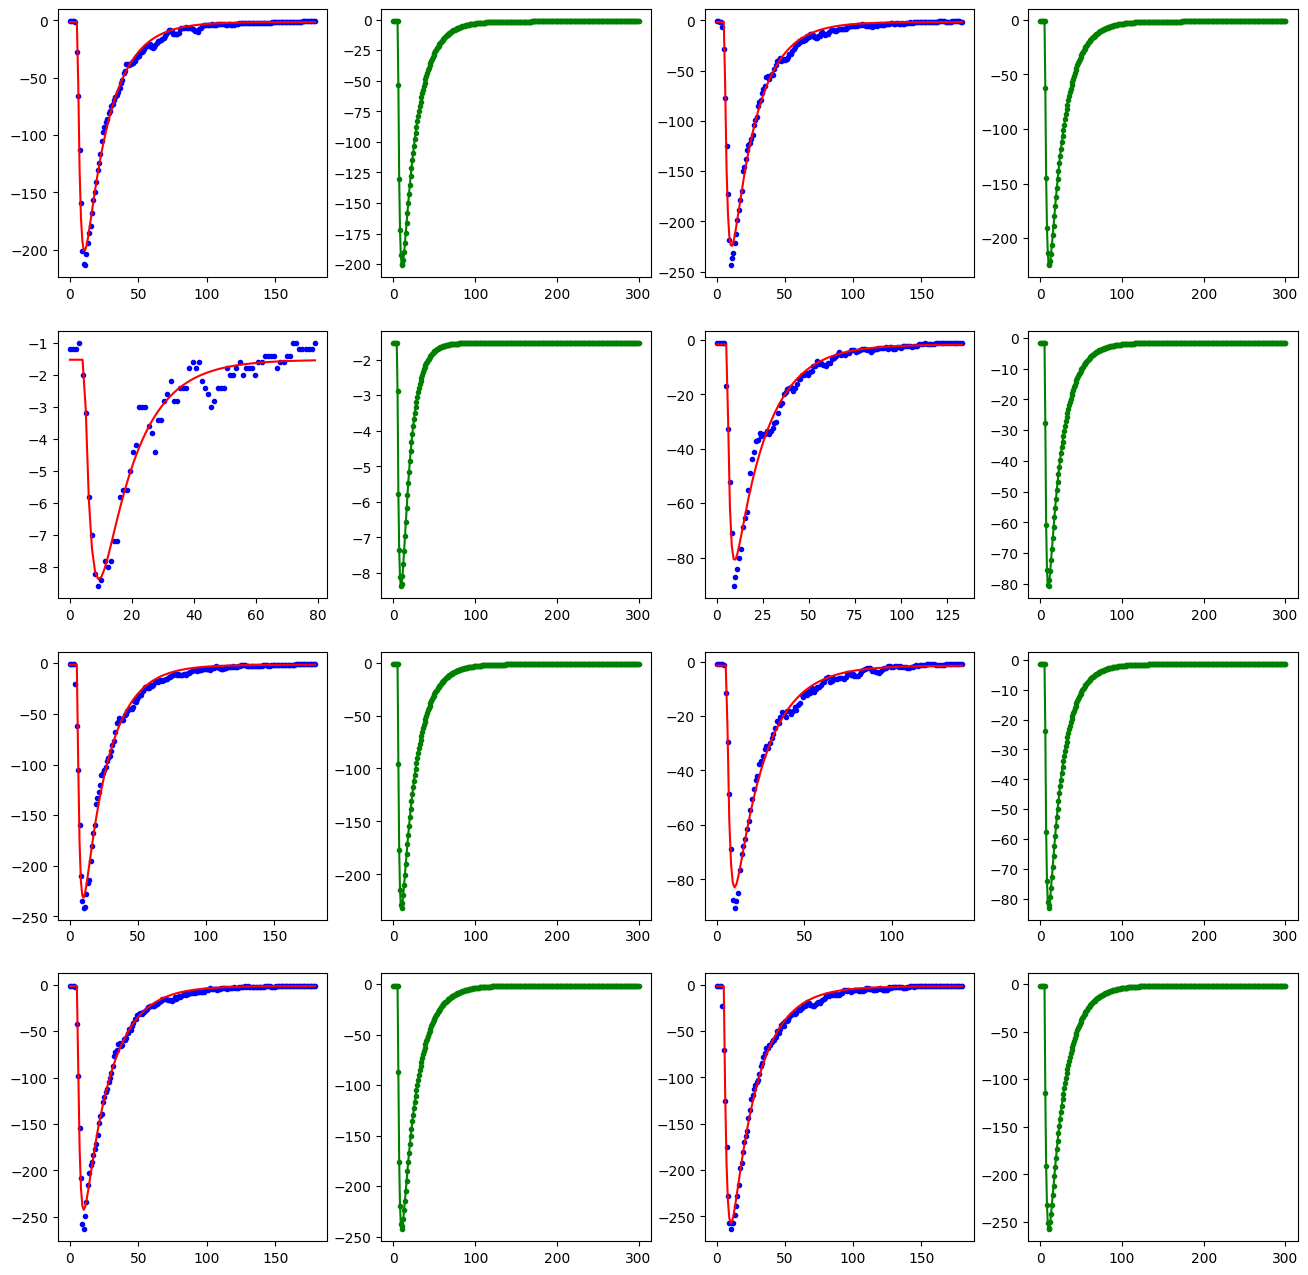

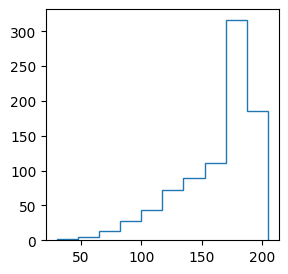

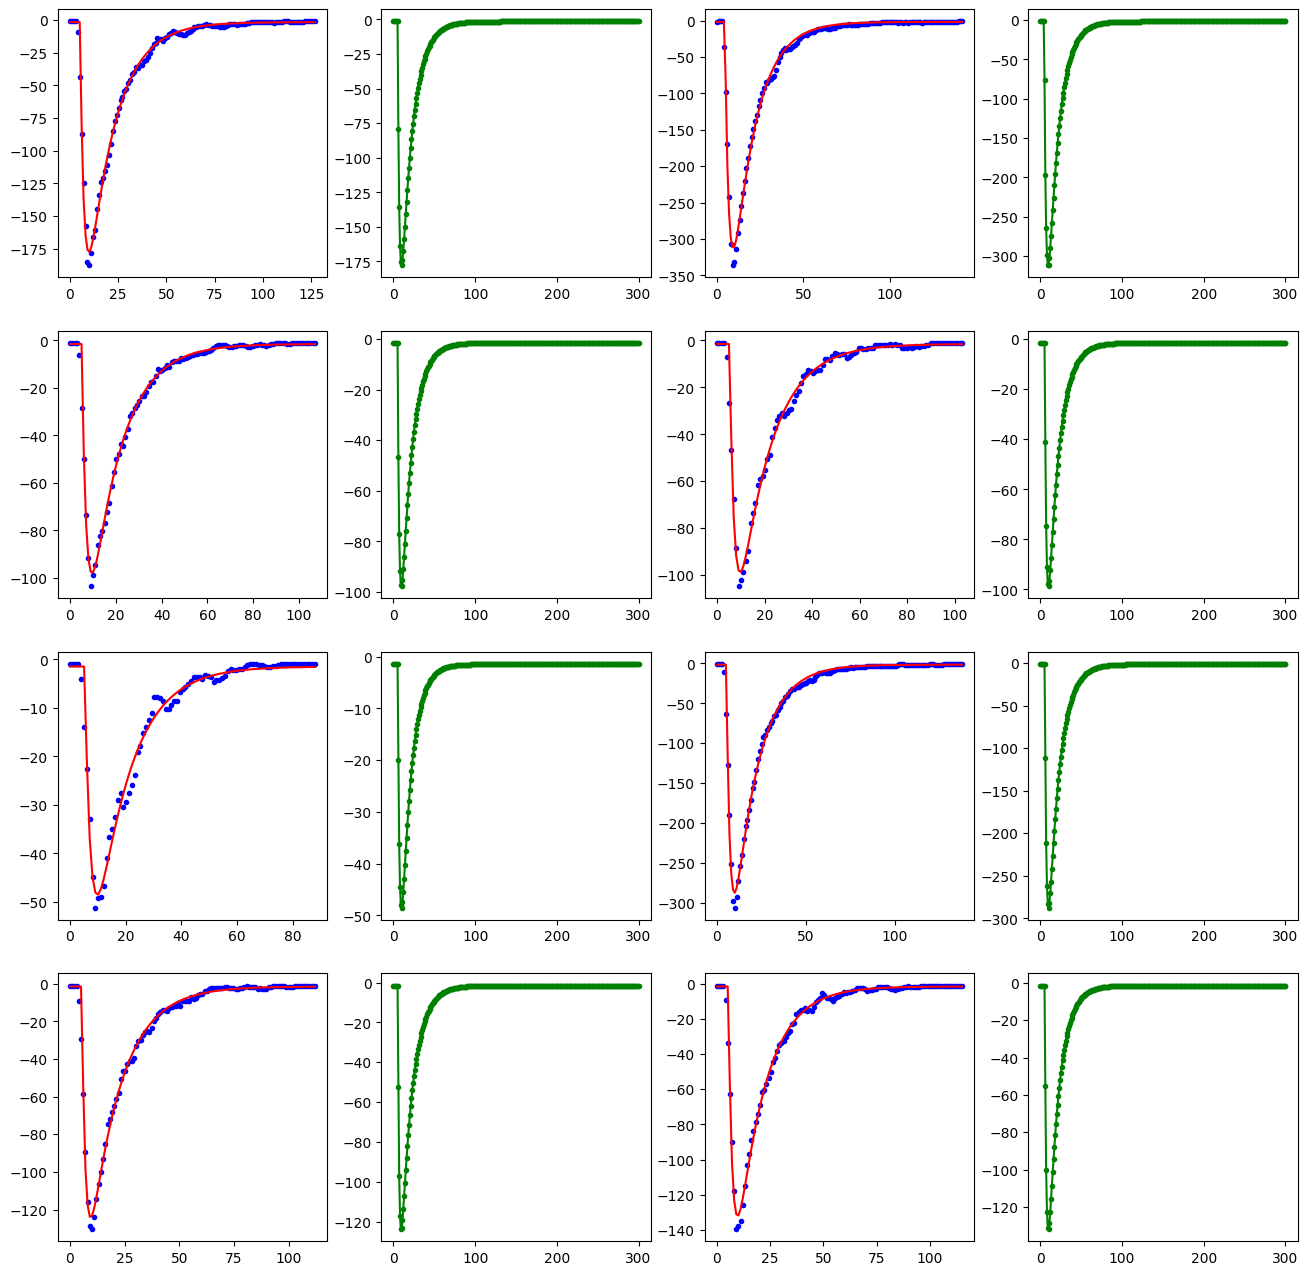

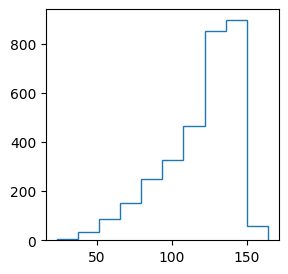

In [115]:
#For PSD simulation code Using simplified functions
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak # Added explicit import for best practice
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# --- 1. CONFIGURATION ---"
FILE_PATH="/home/rsehgal/shared/G4Workshop_Calicut/PSD/"
TREE_NAME = "ftree"

SOURCE_FILE_PATH = FILE_PATH+'buildNeutron/neutron.mac.root' 
listOfSampledNeutronPulse,samplesTiming=ProcessDataFile(SOURCE_FILE_PATH,TREE_NAME,plotPulses=False)

##averageNeutronPulse,samplesTiming=ProcessDataFile(SOURCE_FILE_PATH,TREE_NAME)
##averageNeutronPulse,samplesTiming=ProcessDataFile(SOURCE_FILE_PATH,TREE_NAME)


SOURCE_FILE_PATH = FILE_PATH+'build/gamma.mac.root' 
#averageGammaPulse,samplesTiming=ProcessDataFile(SOURCE_FILE_PATH,TREE_NAME)
listOfSampledGammaPulse,samplesTiming=ProcessDataFile(SOURCE_FILE_PATH,TREE_NAME,plotPulses=False)



Gamma PSD : [np.float64(0.02335806981251069), np.float64(19.943014662145618)]
Neutron PSD : [np.float64(0.02451262596071076), np.float64(25.57148802158605)]
3185 870
[0.02196995 0.01388515 0.03830629 ... 0.01862722 0.02302664 0.02221635]
[20.43842873 19.70658977 20.53372672 ... 25.5789597  24.77894269
 24.92805185]


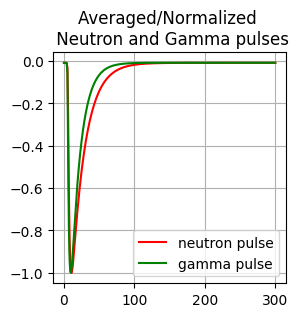

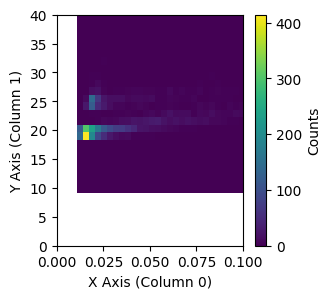

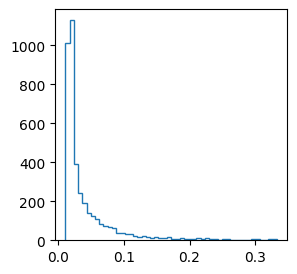

In [118]:
import matplotlib.pyplot as plt
plt.figure(figsize=(3,3))
averageNeutronPulse=AveragePulse(listOfSampledNeutronPulse)
averageGammaPulse=AveragePulse(listOfSampledGammaPulse)
normalizedNeutronPulse=max_normalize(averageNeutronPulse)
normalizedGammaPulse=max_normalize(averageGammaPulse)
plt.plot(samplesTiming,normalizedNeutronPulse ,"r-",label="neutron pulse")
plt.plot(samplesTiming,normalizedGammaPulse,"g-",label="gamma pulse")
plt.title("Averaged/Normalized \n Neutron and Gamma pulses")
plt.grid()
plt.legend()
plt.savefig("ngamma.png")

print(f"Gamma PSD : {PSD(normalizedGammaPulse,samplesTiming)}")
print(f"Neutron PSD : {PSD(normalizedNeutronPulse,samplesTiming)}")

numOfGammaPulses = len(listOfSampledGammaPulse)
numOfNeutronPulses = len(listOfSampledNeutronPulse)

print(numOfGammaPulses,numOfNeutronPulses)

psdList=[]
for i in range(0,numOfGammaPulses):
    normalizedPulse=max_normalize(listOfSampledGammaPulse[i])
    psdList.append(PSD(normalizedPulse,samplesTiming))


for i in range(0,numOfNeutronPulses):
    normalizedPulse=max_normalize(listOfSampledNeutronPulse[i])
    psdList.append(PSD(normalizedPulse,samplesTiming))

psdArray=np.array(psdList)

x = psdArray[:, 0] 
y = psdArray[:, 1]
print(x)
print(y)
# Create the 2D histogram
plt.figure(figsize=(3,3))
plt.hist2d(x, y,bins=100) #, cmap='virdis')
plt.colorbar(label='Counts')
plt.xlabel('X Axis (Column 0)')
plt.ylabel('Y Axis (Column 1)')
plt.ylim(0,40)
plt.xlim(0,0.1)


plt.figure(figsize=(3,3))
plt.hist(x,histtype="step",bins=50)
plt.show()        
#integration
#shortGate=80
#longGate=150

#Integrate(normalizedGammaPulse,samplesTiming,0,120)
#Integrate(normalizedNeutronPulse,samplesTiming,0,120)


Total num of events :  100
[[-1.5        -1.5        -1.5        ... -1.5000095  -1.50000894
  -1.50000841]
 [-1.5        -1.5        -1.5        ... -1.50000921 -1.50000866
  -1.50000814]
 [-1.5        -1.5        -1.5        ... -1.50000056 -1.50000053
  -1.50000049]
 ...
 [-1.7        -1.7        -1.7        ... -1.70000074 -1.70000069
  -1.70000065]
 [-1.7        -1.7        -1.7        ... -1.70001542 -1.70001451
  -1.70001367]
 [-1.5        -1.5        -1.5        ... -1.50000888 -1.50000834
  -1.50000784]]
Total Number of Good pulses : 89
Overall Max Time : 457
Mean Pulse lenght : 169.11111111111111


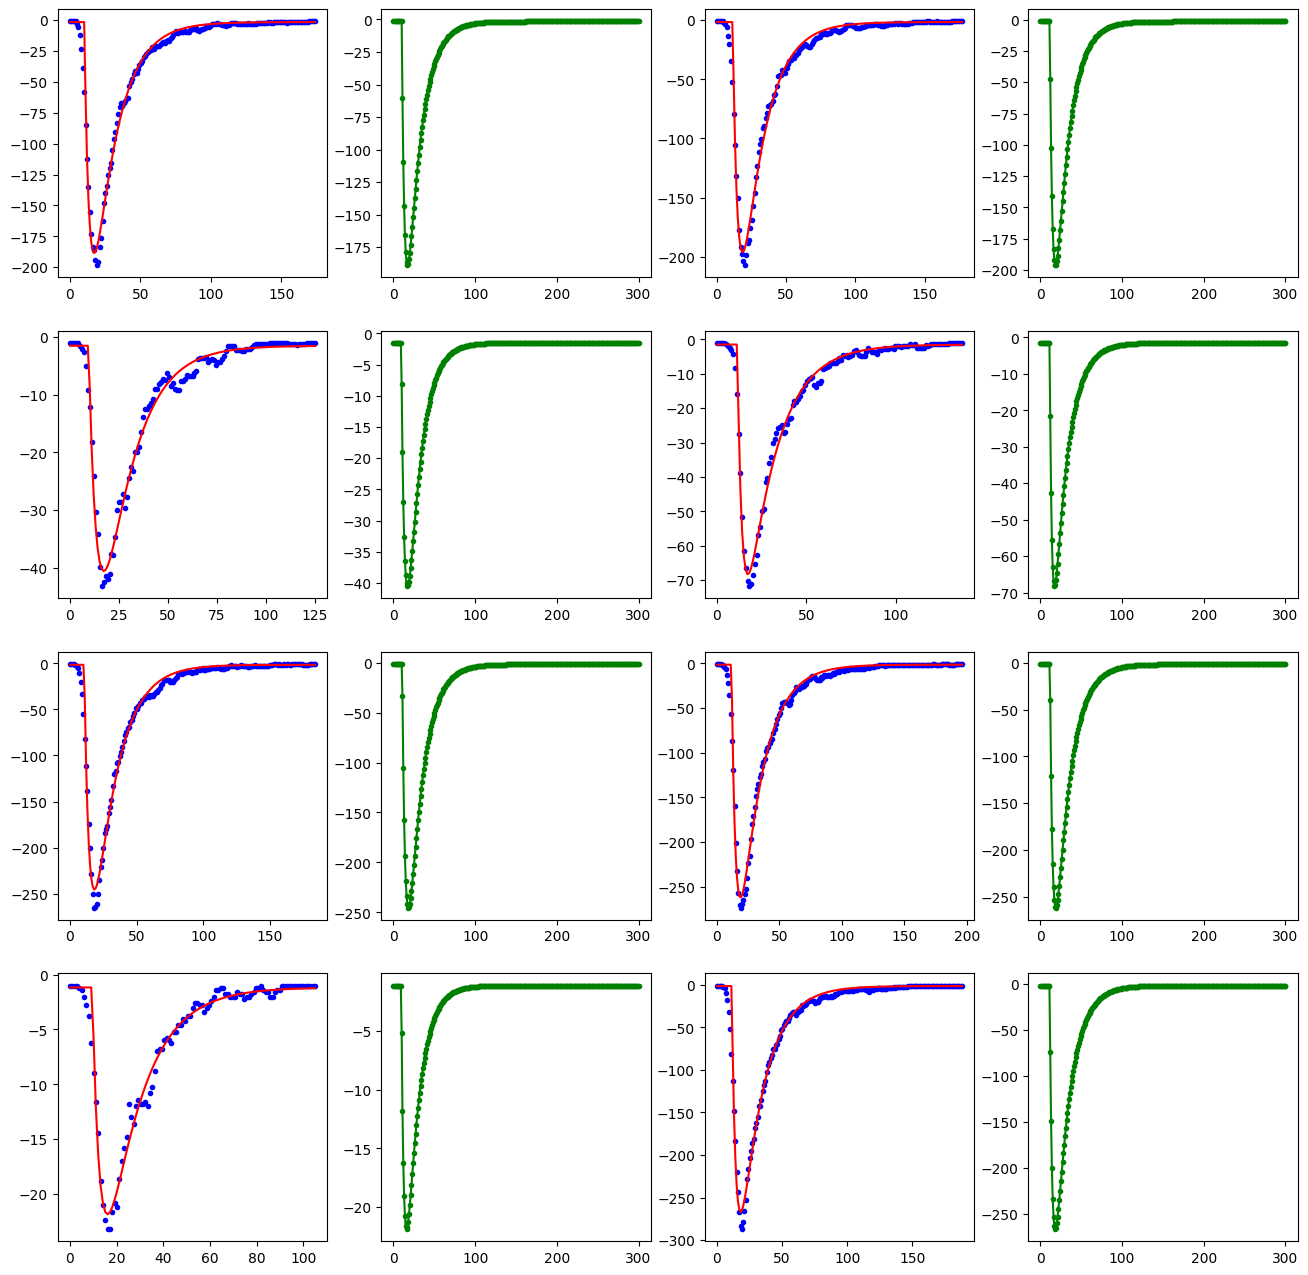

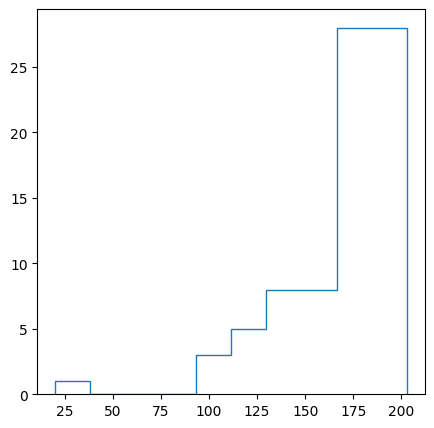

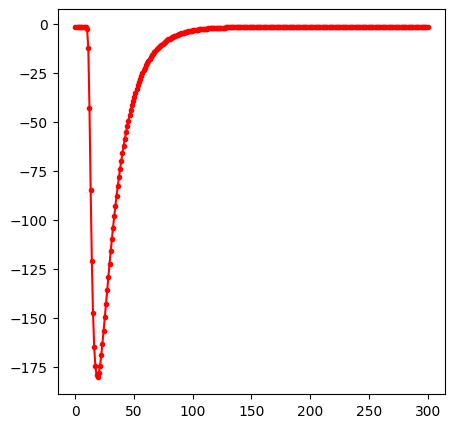

In [43]:
#For PSD simulation code
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak # Added explicit import for best practice
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score



# --- 1. CONFIGURATION ---
#FILE_PATH="/home/rsehgal/shared/"
#FILE_PATH="/Users/rsehgal/Codes/G4Workshop_Calicut/PSD/"
FILE_PATH="/home/rsehgal/shared/G4Workshop_Calicut/PSD/"
#SOURCE_FILE_PATH = FILE_PATH+'buildNeutron/neutron.mac.root' 
#SOURCE_FILE_PATH = FILE_PATH+'build/gamma.mac.root' 
SOURCE_FILE_PATH = FILE_PATH+'buildNeutron/neutron.mac.root' 
#SOURCE_FILE_PATH = FILE_PATH+'DataF_Bar_Na22_2min.root' 
TREE_NAME = "ftree"

# --- 2. FILE & TREE ACCESS ---
# Use 'with' for safe file handling
segregatedCharge=[]
hei=[]
rows=5
cols=5
plotPulses=True
listOfPulses=[]
plt.figure(figsize=(16,16))
#branchList=['Energy','EnergyShort','Samples']
branchList=['Samples']
counter=0

timingSamples = np.linspace(0,300,300)
listOfSampledPulses=[]


with uproot.open(SOURCE_FILE_PATH) as file:
    tree = file[TREE_NAME]
    

    # --- 3. DATA READING (Optimized) ---
    # Read only the first event (entry_stop=1) and the 'Samples' branch
    if plotPulses:
        data = tree.arrays(
            branchList, 
            entry_start=0, 
            entry_stop=100, 
            library="ak"
        )
    else:
        data = tree.arrays(
            branchList,
            #entry_start=0, 
            #entry_stop=5000, 
            library="ak"
        )
    print("Total num of events : ",len(data))

    pulseLenList=[]
    maxTime=0
    for pulseNum in range(0,len(data)):
    #for pulseNum in range(0,50):
        
        #print(data[pulseNum]["Samples"])
        
        timePts=np.linspace(0,len(data[pulseNum]["Samples"]),len(data[pulseNum]["Samples"]))
        #plt.plot(timePts,data[1]["Samples"])
        
        counts, bin_edges = np.histogram(data[pulseNum]["Samples"], bins=1024)

        
        
        #print(f"Pulse length : {len(counts)}")
        
        #print(counts)
        mask = counts>0
        counts = counts[mask]
        if len(counts) == 0 :
            continue
        #counter+=1
        N=8
        last_N_points = counts[-N:]
        counts = np.concatenate((last_N_points, counts))
        counts = -1.*counts
        counts = moving_average_np(counts,5)
        counts = counts.tolist()
        #print(counts)
        #print(len(counts))
        time_points=np.linspace(0,len(counts),len(counts))
        
        #plt.scatter(time_points,counts,marker=".",color="blue")
        #plt.plot(time_points,counts,"r.-")
        #print(f"================= {counter} ======================")

        
        try:
            popt=FitPulse(time_points,counts)
            fitted_pulse = pulse_model(time_points, *popt)
            sampled_pulse = pulse_model(timingSamples, *popt)
            listOfSampledPulses.append(sampled_pulse)
            
            r2 = r2_score(counts, fitted_pulse)
            if 0 and r2 > 0.9:
                print(f"================= {counter} ======================")
                print(f"Pulse length : {len(counts)}")
                print(f"R-squared: {r2:.3f}")

            if 1 and r2 > 0.9:
                pulseMaxTime = np.max(data[pulseNum]["Samples"])
                #print(f"Pulse Max Time : {pulseMaxTime}")
                if pulseMaxTime > maxTime :
                    maxTime = pulseMaxTime
                    
                
            if r2 > 0.9 :
                counter+=1
                pulseLenList.append(len(counts))
                if counter <= 16:
                    plt.subplot(4,4,counter)
                    plt.scatter(time_points,counts,marker=".",color="blue")
                    plt.plot(time_points,fitted_pulse,'r-')
                    counter += 1
                    plt.subplot(4,4,counter)
                    plt.plot(timingSamples,sampled_pulse,marker=".",color="green")
                    
            #else : 
            #    print("Warning: Fit quality is poor.")

            
            

            # You can set a threshold to "detect" a bad fit
            #if r2 < 0.5: # Example threshold
                #print("Warning: Fit quality is poor.")
                        
        except ValueError as e:
            #print(f"Skipping event due to bounds error: {e}")
            continue  # Skips the rest of this loop iteration
        except RuntimeError:
            #print("Skipping event: Fit failed to converge.")
            continue

        #if counter==16:
            #break
        
        #if 1: 
        #    popt=FitPulse(time_points,counts)
        #    fitted_pulse = pulse_model(time_points, *popt)
        #    #plt.scatter(time_points,counts,marker=".",color="blue")
        #    plt.plot(time_points,fitted_pulse,'r-')
        

    listOfSampledPulses = np.array(listOfSampledPulses)
    print(listOfSampledPulses)
    
    print(f"Total Number of Good pulses : {counter}")

    print(f"Overall Max Time : {maxTime}")
    
    plt.figure(figsize=(5,5))
    plt.hist(pulseLenList,histtype="step")
    print(f"Mean Pulse lenght : {np.mean(pulseLenList)}")

    averagePulse = listOfSampledPulses.mean(axis=0)
    plt.figure(figsize=(5,5))
    plt.plot(timingSamples,averagePulse,"r.-")

    
    '''
    plt.figure(figsize=(5,5))
    plt.plot(timingSamples,listOfSampledPulses[0],"r.-")

    plt.figure(figsize=(5,5))
    plt.plot(timingSamples,listOfSampledPulses[1],"g.-")
    '''
    
    '''
    plt.figure(figsize=(5,5))
    pulse1=data[1]["Samples"]
    pulse1_norm = max_normalize(pulse1)
    time_points_1=np.linspace(0,len(pulse1_norm),len(pulse1_norm))
    popt=FitPulse(time_points_1,pulse1_norm.tolist())
    fitted_pulse_1 = pulse_model(time_points_1, *popt)
    plt.plot(time_points_1,fitted_pulse_1,'r-')
    
    pulse2=data[2]["Samples"]
    pulse2_norm = max_normalize(pulse2)
    time_points_2=np.linspace(0,len(pulse2_norm),len(pulse2_norm))
    popt=FitPulse(time_points_2,pulse2_norm.tolist())
    fitted_pulse_2 = pulse_model(time_points_2, *popt)
    plt.plot(time_points_2,fitted_pulse_2,'g-')

    print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
    '''
    
    '''
    N=2
    last_N_points = counts[-N:]
    counts = np.concatenate((last_N_points, counts))
    counts = -1.*counts
    counts = moving_average_np(counts,5)
    counts = counts.tolist()
   
    
    print(counts)
    print(len(counts))
    time_points=np.linspace(0,len(counts),len(counts))
    print(len(time_points))
    popt=FitPulse(time_points,counts)
    fitted_pulse = pulse_model(time_points, *popt)
    plt.scatter(time_points,counts,marker=".")
    plt.plot(time_points,fitted_pulse,'r-',label="Gamma Pulse")

    #plt.plot(time_points,counts,"r.-")
    '''
    #ax.invert_yaxis()


In [24]:
np.linspace(0,400,1)

array([0.])

In [ ]:
2+3